# Falcon One — simulação de voo com RocketPy


Este fluxo usa a biblioteca **RocketPy** e arquivos locais do modelo: curva do motor (`FalconOneV1.eng`), arrasto em função do Mach (`OnArrasto.csv` / `OffArrasto.csv`) e os parâmetros geométricos do foguete. A célula seguinte garante que o pacote esteja disponível no interpretador.

In [1]:
#%pip install rocketpy

O que se segue monta, em sequência, o **ambiente** (coluna de ar e vento), o **motor Falcon One**, o **veículo** com geometria e arrasto, e por fim integra a **trajetória** (`Flight`). Os imports abaixo carregam as classes usadas nessa cadeia.


In [2]:
from rocketpy import Environment, Flight, Rocket, SolidMotor

Saída em **SVG** para os gráficos gerados pelo matplotlib: melhor nitidez ao ampliar figuras nos relatórios.


In [3]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

## Modelo para a simulação


### Ambiente no local de lançamento


O objeto `Environment` ancora o **local** (latitude, longitude, elevação do solo) e passa a prover, junto com o modelo atmosférico, a **densidade do ar**, **temperatura**, **velocidade do som** e **perfil de vento** em função da altitude — entradas diretas para arrasto, Mach e forças aerodinâmicas ao longo da trajetória simulada.


Launch Site Details

Launch Date: 2026-06-09 11:43:06 UTC
Launch Site Latitude: -21.90795°
Launch Site Longitude: -48.96156°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 0.0 m



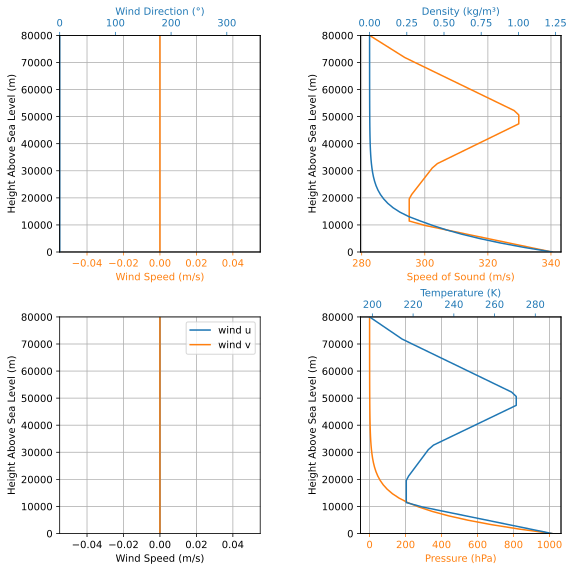


Gravity Details

Acceleration of gravity at surface level:    9.7803 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5379 m/s²


Launch Site Details

Launch Date: 2026-06-09 11:43:06 UTC
Launch Site Latitude: -21.90795°
Launch Site Longitude: -48.96156°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 0.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 1013.25 hPa
Surface Temperature: 288.15 K
Surface Air Density: 1.225 kg/m³
Surface Speed of Sound: 340.29 m/s


Earth Model Details

Earth Radius at Launch site: 6378.14 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



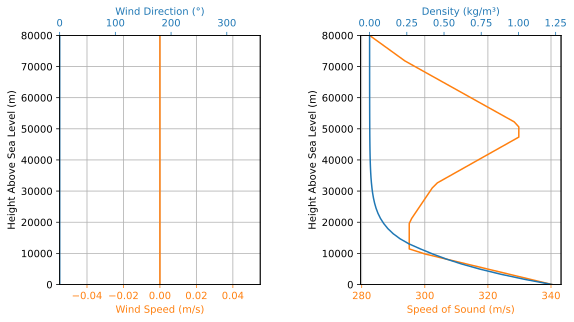

In [4]:
# Configura as condições do local e data de lançamento
from datetime import datetime, timedelta
from rocketpy import Environment

tomorrow = datetime.now() + timedelta(days=1)

env = Environment(date=tomorrow)

env.set_location(latitude=-21.90795, longitude=-48.96156)

env.prints.launch_site_details()

env.set_atmospheric_model(type="standard_atmosphere")

env.plots.atmospheric_model()

env.info()

A **data e hora** em UTC escolhidas abaixo selecionam qual ciclo da previsão **GFS** alimenta a coluna atmosférica (no código, o dia é deslocado em relação à data corrente para fixar o cenário meteorológico usado na integração).


O modelo **Forecast / GFS** substitui uma atmosfera padrão estática por perfis horizontais consistentes com a previsão na época definida. Avisos do RocketPy sobre variáveis incompletas em algumas camadas significam apenas interpolação entre níveis do arquivo — não impedem o uso da simulação.


`env.info()` resume **gravidade local**, **local do lançamento**, **condições na superfície** e traça perfis de densidade, temperatura e vento — o mesmo pacote de dados que o integrador usará no `Flight`.


### Motor sólido Falcon One

O **`SolidMotor`** combina a curva de empuxo do arquivo **`FalconOneV1.eng`** com a geometria dos **três grãos**, **bocal** e massas/inércias secas. Durante a integração, o empuxo e a massa de propelente consumida alimentam as equações de movimento e o deslocamento do centro de massa do sistema.


In [5]:
# %%
# ------------------------- MOTOR -------------------------
from rocketpy import SolidMotor

FalconOne = SolidMotor(
    # Fonte da curva de empuxo
    thrust_source="meteor-RASP_campeaon.eng",

    # Tempo de queima em segundos
    burn_time=1.4,

    # Massa do motor vazio (975.00 g -> 0.975 kg)
    dry_mass=0.975,

    # Inércia do motor vazio (convertida de g*mm² para kg*m²)(Ixx, Iyy, Izz)
    dry_inertia=(1.0047, 0.9756, 0.0298),

    # Centro de massa seco do motor no seu sistema (origem no bocal)
    center_of_dry_mass_position=0.10,

    # Posição da saída do bocal (origem do sistema do motor)
    nozzle_position=0.0,

    # Raio da SAÍDA do bocal (12.6 mm -> 0.0126 m)
    nozzle_radius=0.0126,

    # Raio da GARGANTA do bocal (4.9 mm -> 0.0049 m)
    throat_radius=0.0049,

    # Número de grãos de propelente
    grain_number=3,
    
    # Densidade do propelente em kg/m³
    grain_density=2050,
    
    # Raio externo do grão (21 mm -> 0.021 m)
    grain_outer_radius=0.021,
    
    # Raio interno inicial do grão (8.9 mm -> 0.0089 m)
    grain_initial_inner_radius=0.0089,
    
    # Altura/comprimento de um grão (80 mm -> 0.080 m)
    grain_initial_height=0.080,
    
    # Separação entre os grãos (0.5 mm -> 0.0005 m)
    grain_separation=0.0005,
    
    # Posição do centro de massa dos grãos (no sistema do motor)
    grains_center_of_mass_position=0.18,

    # Orientação do sistema de coordenadas do motor
    coordinate_system_orientation="nozzle_to_combustion_chamber"
)



/home/colombs/Documentos/falcon2/RPy-Falcon6/venv/lib/python3.12/site-packages/rocketpy/motors/motor.py:998: UserWarning: burn_time argument (0, 1.4) is out of thrust source time range. Using thrust_source boundary times instead: (0, 1.1408) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


Os comprimentos medidos ao longo do eixo do motor (**bocal, CM seco, CM dos grãos**) definem onde nasce o vetor de empuxo e como a inércia do conjunto motor–estrutura se acopla ao foguete. Referência: [posições no RocketPy](https://docs.rocketpy.org/en/latest/user/positions.html).


`FalconOne.info()` confronta o `.eng` com a geometria dos grãos: empuxo máximo, impulso total, massa de propelente e o gráfico **empuxo × tempo** — conferência antes de acoplar o motor ao veículo.


Nozzle Details
Nozzle Radius: 0.0126 m
Nozzle Throat Radius: 0.0049 m

Grain Details
Number of Grains: 3
Grain Spacing: 0.0005 m
Grain Density: 2050 kg/m3
Grain Outer Radius: 0.021 m
Grain Inner Radius: 0.0089 m
Grain Height: 0.08 m
Grain Volume: 0.000 m3
Grain Mass: 0.186 kg

Motor Details
Total Burning Time: 1.4 s
Total Propellant Mass: 0.559 kg
Structural Mass Ratio: 0.636
Average Propellant Exhaust Velocity: 1266.473 m/s
Average Thrust: 505.871 N
Maximum Thrust: 752.8582 N at 0.9799 s after ignition.
Total Impulse: 708.219 Ns



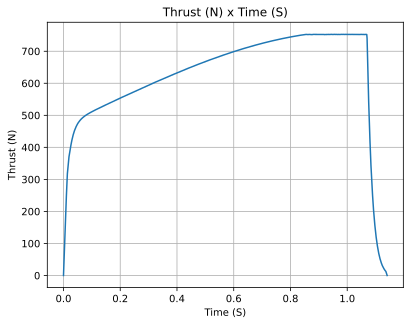

In [6]:
# Imprime um resumo completo do motor para verificar se todos os dados foram carregados corretamente
FalconOne.info()


### Foguete e aerodinâmica


`FalconOneRocket` agrega **massa e inércia** da estrutura sem motor, **raio de referência** para arrasto, e duas curvas **Cd(Mach)** — motor ligado (`OnArrasto.csv`) e desligado (`OffArrasto.csv`) — que o integrador troca conforme o estado da queima. O referencial é **nariz → cauda**; o centro de massa sem motor está medido a partir da ponta da ogiva.


In [7]:
# ------------------------- FOGUETE -------------------------
from rocketpy import Rocket

FalconOneRocket = Rocket(
    # Raio do foguete (diâmetro máx. 7,96 cm -> raio 0,0398 m)
    radius=0.0398,

    # Massa do foguete SEM o motor (2851 g -> 2.851 kg)
    mass=2.851,

    # Inércia do foguete (Ixx, Iyy, Izz) em kg*m^2
    inertia=(0.499, 0.499, 0.004),

    # Arquivo com a curva de arrasto por velocidade mach com motor desligado
    power_off_drag='OffArrasto.csv',

    # Arquivo com a curva de arrasto por velocidade mach com motor ligado
    power_on_drag='OnArrasto.csv',

    # Posição do centro de massa sem o motor (74 cm -> 0,74 m)
    # Medido a partir da ponta da ogiva (ponta do foguete)
    center_of_mass_without_motor=0.74,

    coordinate_system_orientation="nose_to_tail"
)

`add_motor` alinha o **FalconOne** ao eixo do foguete: o parâmetro de posição fixa a **saída do bocal** no referencial da ogiva, de modo que empuxo, arrasto e momentos atuem sobre a mesma linha de base estrutural.


In [8]:

# A 'position' é a distância (em metros) da ponta da ogiva até a saída do bocal do motor.
FalconOneRocket.add_motor(FalconOne, position=1.41)

#### Superfícies e contribuição aerodinâmica


Ogiva em **série de potência**, **quatro aletas trapezoidais** e **transição de cauda** fecham a geometria externa: o RocketPy calcula a distribuição normal em função do Mach e da incidência efetiva, alimentando forças, momentos e a **margem estática** ao longo do voo. Todas as posições seguem o mesmo eixo **nariz–cauda** (ponta da ogiva na origem). [Referência de posicionamento](https://docs.rocketpy.org/en/latest/user/positions.html).

In [9]:
# Adiciona a Ogiva ao foguete
ogiva = FalconOneRocket.add_nose(
    length=0.237,       # Comprimento da ogiva em metros
    kind='powerseries',  # Parabólica (OpenRocket)
    power=1.0,
    position=0        # A ponta da ogiva é a origem (0) do foguete
)

# Adiciona as Aletas ao foguete
aletas = FalconOneRocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.08,
    tip_chord=0.03,
    span=0.115,
    position=1.26,
    cant_angle=0,
)

# Adiciona uma Cauda/Transição
cauda = FalconOneRocket.add_tail(
    top_radius=0.0398,   
    bottom_radius=0.025,  
    length=0.06,
    position=1.36
)


O desenho esquemático e o `info()` consolidam **dimensões**, **margem estática** inicial e coerência entre componentes — sanity check antes do `Flight`.


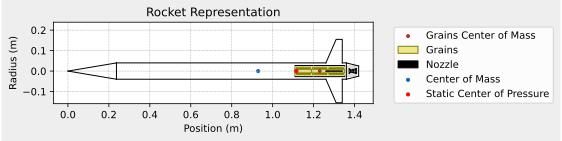

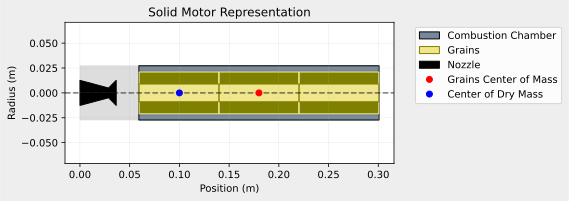

In [10]:
# Verificando a representação do foguete
FalconOneRocket.plots.draw()
FalconOne.plots.draw()



Inertia Details

Rocket Mass: 2.851 kg (without motor)
Rocket Dry Mass: 3.826 kg (with unloaded motor)
Rocket Loaded Mass: 4.385 kg
Rocket Structural Mass Ratio: 0.872
Rocket Inertia (with unloaded motor) 11: 1.740 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.711 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.034 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0398 m
Rocket Frontal Area: 0.004976 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.145 m
Rocket Center of Dry Mass - Nozzle Exit: 0.525 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.345 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.044 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 12.488/rad
Tail Lift Coefficient Deri

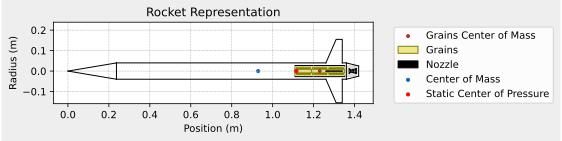


Mass Plots
----------------------------------------


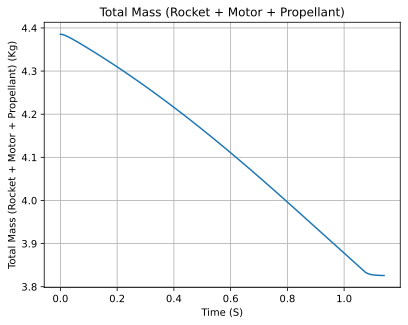

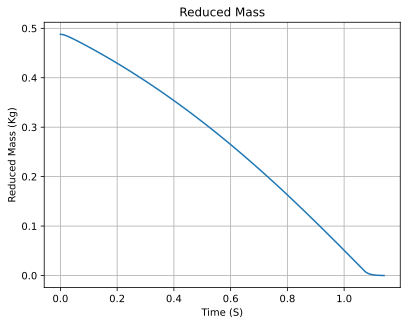


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


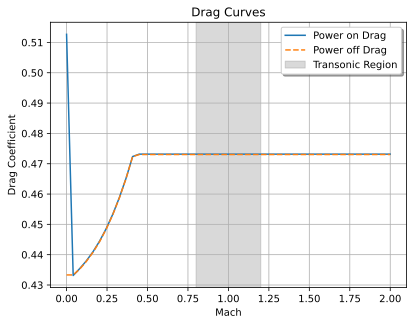


Stability Plots
--------------------


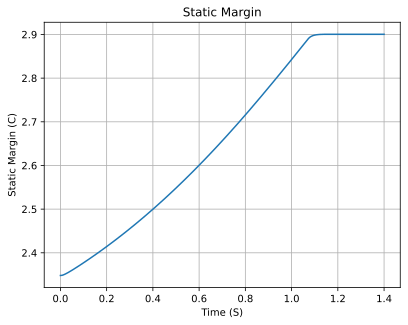

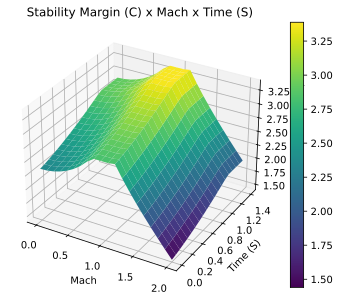


Thrust-to-Weight Plot
----------------------------------------


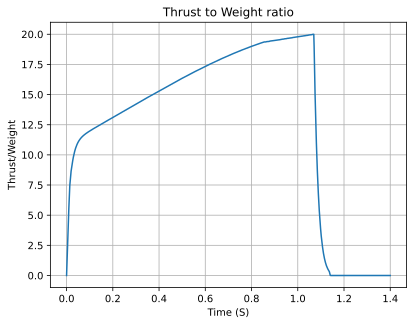

In [11]:
FalconOneRocket.all_info()

#### Recuperação por paraquedas


O paraquedas registrado abaixo usa **`Cd·S`**, **gatilho no apogeu** (máximo da trajetória integrada) e um modelo simples de **atraso de ejeção** e **ruído de altímetro**. Na descida, o integrador troca a dinâmica de voo livre por uma força de arrasto efetiva ligada a esse produto, reduzindo velocidade terminal antes do impacto.


In [12]:
# %%
# ------------------------- SISTEMA DE RECUPERAÇÃO -------------------------

# Adiciona o Paraquedas Principal ao foguete
paraquedas_principal = FalconOneRocket.add_parachute(
    "ParaQuedas",       # Nome do paraquedas
    cd_s=2.3277,          # Vamos calcular juntos (Cd * Área)
    trigger="apogee",  # Acionamento no ponto mais alto do voo
    sampling_rate=100, # Taxa de amostragem do altímetro em Hz (ex: 150)
    lag=1.5,           # Atraso da ejeção em segundos (ex: 1.5)
    noise=(0, 0.1, 0.5)  # Ruído do altímetro (média, desvio_padrão, correlação)
)


Cada nova execução de `add_parachute` **acumula** outro sistema na mesma instância de `FalconOneRocket`; o `Flight` enxergaria desdobramentos e massas repetidas. Para iterar cenários, volte à montagem do foguete ou esvazie a lista antes de registrar de novo:

```python
FalconOneRocket.parachutes.clear()
```


## Integração da trajetória (`Flight`)

O objeto **`Flight`** resolve as equações de movimento acoplando **empuxo**, **arrasto**, **forças aerodinâmicas nas superfícies**, **vento em camadas** e a cinemática do **trilho** (`rail_length`, `inclination`, `heading`). A saída é o estado completo do veículo ao longo do tempo até o evento final — impacto ou descida sob paraquedas, conforme o modelo.


In [13]:
test_flight = Flight(
    rocket=FalconOneRocket,
    environment=env,
    rail_length=4,
    inclination=85,
    heading=5,
    verbose=True,
)

Current Simulation Time: 219.9899 s
>>> Simulation Completed at Time: 202.2530 s


In [14]:
# Preserva referencia ao voo principal (cells posteriores sobrescrevem test_flight)
main_flight = test_flight

## Séries temporais e diagnósticos

`all_info()` agrega **históricos** (altura, velocidade, Mach, ângulos, carga aerodinâmica, estabilidade, etc.) e visualizações agrupadas por tema: é o retrato pós-voo do mesmo modelo que acabou de ser integrado. Variáveis individuais permanecem acessíveis nos atributos do `Flight` para gráficos próprios.



Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 0.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.998 | e1: -0.044 | e2: 0.002 | e3: -0.044
Euler Angles - Spin φ : 0.00° | Nutation θ: -5.00° | Precession ψ: -5.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.348 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 5.00°


Rail Departure State

Rail Departure Time: 0.287 s
Rail Departure Velocity: 30.747 m/s
Rail Departure Stability Margin: 2.454 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 14.062
Rail Departure Reynolds Number: 1.675e+05


Burn out State

Burn out time: 1.400 s
Altitude at burn out: 125.726 m (ASL) | 125.726 m (AGL)
Rocket speed at burn out: 153.537 m/s
Freestream velocity a

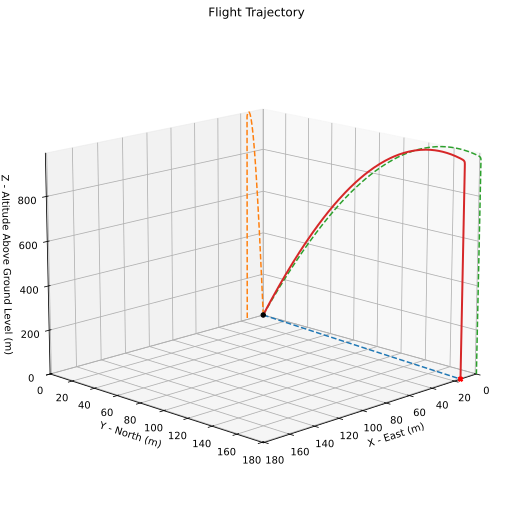



Trajectory Kinematic Plots



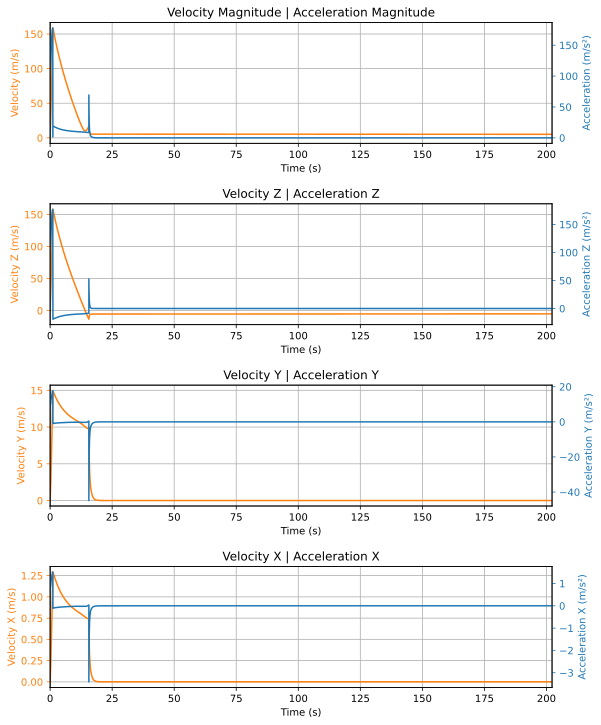



Angular Position Plots



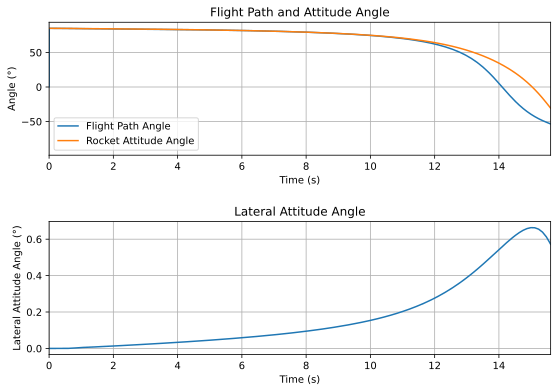



Path, Attitude and Lateral Attitude Angle plots



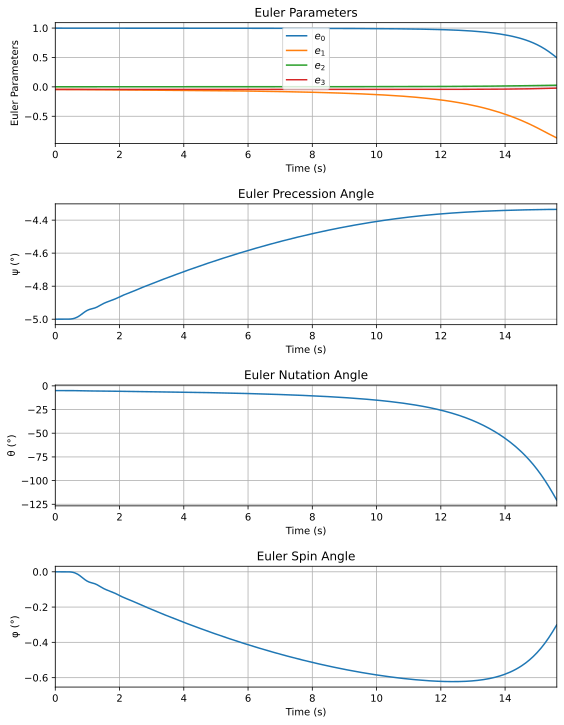



Trajectory Angular Velocity and Acceleration Plots



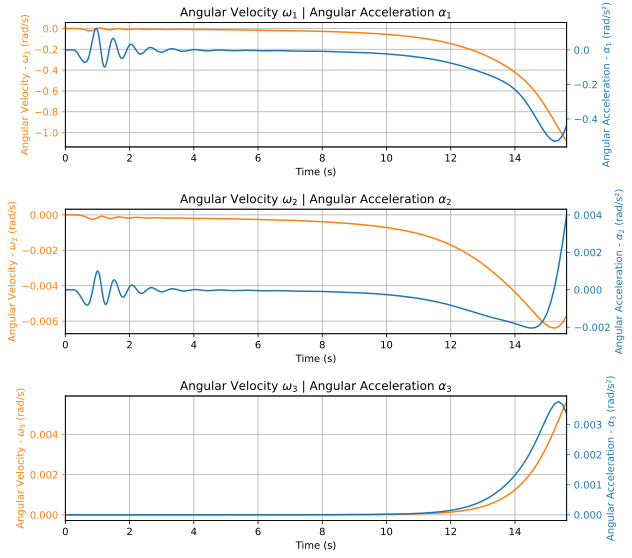



Aerodynamic Forces Plots



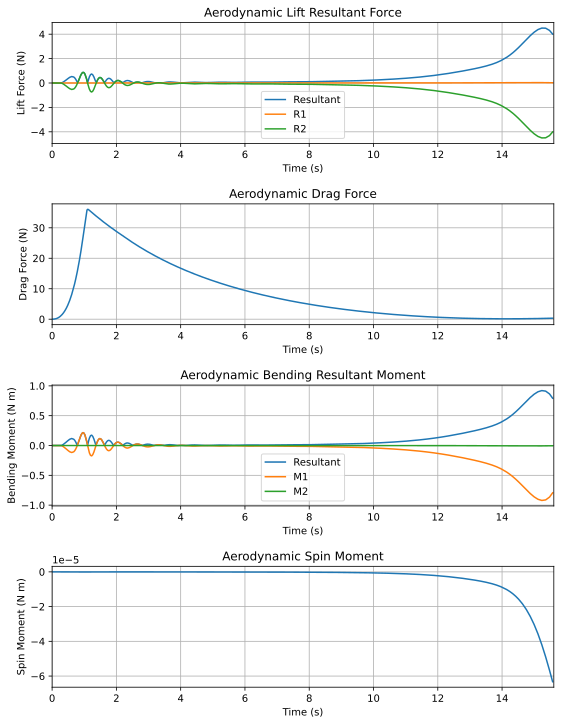



Rail Buttons Bending Moments Plots

No rail buttons were defined. Skipping rail button bending moment plots.


Rail Buttons Forces Plots

No rail buttons were defined. Skipping rail button plots.


Trajectory Energy Plots



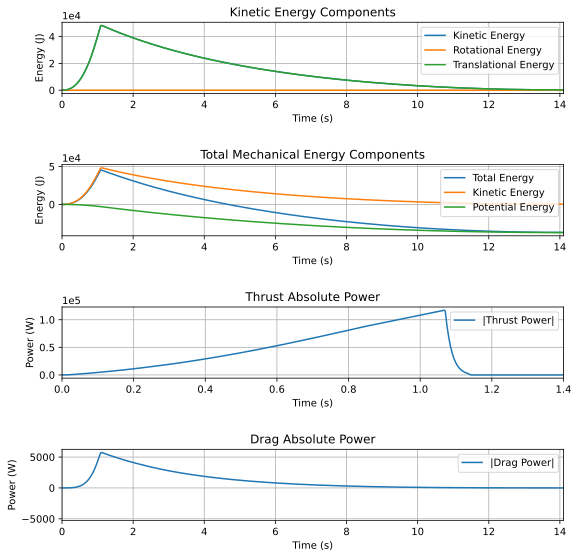



Trajectory Fluid Mechanics Plots



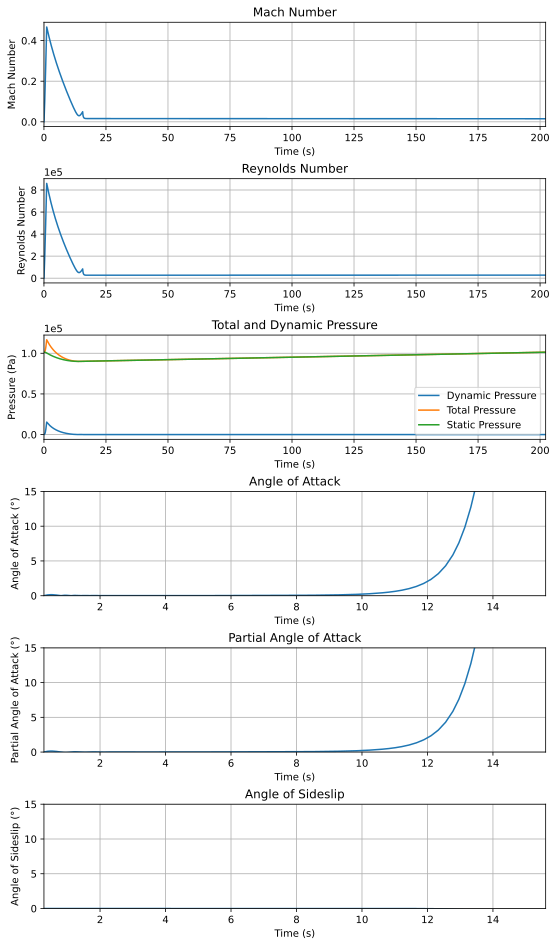



Trajectory Stability and Control Plots



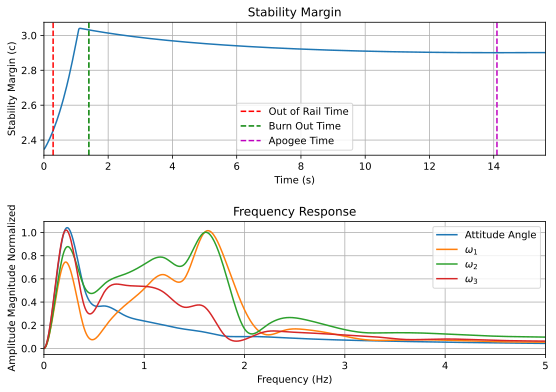



Rocket and Parachute Pressure Plots



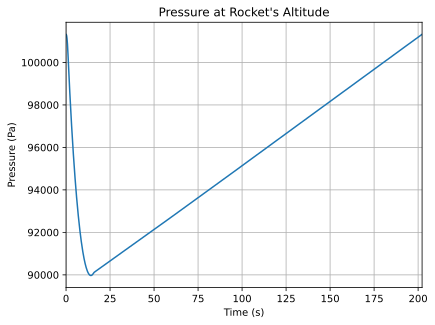


Parachute:  ParaQuedas


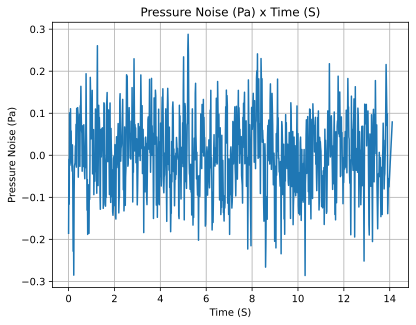

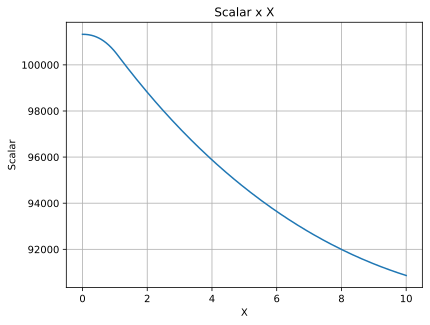

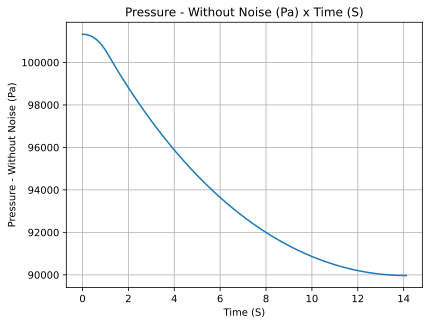

In [15]:
test_flight.all_info()

Exportação **KML**: a mesma trajetória integrada é projetada no globo (Google Earth ou equivalente), útil para inspecionar azimute, distância ao solo e forma da subida em relação ao campo de lançamento.


In [16]:
test_flight.export_kml(
    file_name="Lançamento-LASC2025.kml",
    extrude=True,
    altitude_mode="relative_to_ground",
)

File  Lançamento-LASC2025.kml  saved with success!


/tmp/ipykernel_14271/2701137696.py:1: DeprecationWarning: Moved to FlightDataExporter.export_kml() and will be removed in v1.12.0. Use `rocketpy.simulation.flight_data_exporter.FlightDataExporter.export_kml` instead.
  test_flight.export_kml(


## Sensibilidades em torno do voo nominal

As rotinas abaixo **reaproveitam** o `Flight` já convergido como referência e recalculam grandezas-chave (**apogeu**, **velocidade na saída do trilho**, **estabilidade dinâmica**) quando massa, geometria ou condição de partida mudam — ou seja, leitura de projeto a partir do mesmo núcleo de simulação.


### Apogeu versus massa total

Varrendo a massa do veículo, o gráfico mostra como o **apogeu de referência** se desloca com carga útil ou margem de propelente: trade-off direto entre peso e altitude máxima para o mesmo motor e arrasto.


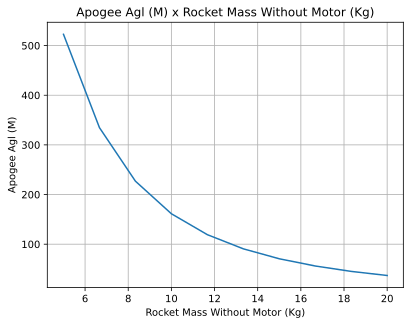

'Function from R1 to R1 : (Rocket Mass without motor (kg)) → (Apogee AGL (m))'

In [17]:
from rocketpy.utilities import apogee_by_mass

apogee_by_mass(flight=test_flight, min_mass=5, max_mass=20, points=10, plot=True)

### Velocidade na saída do trilho versus massa

Na saída do trilho, o foguete já precisa de **velocidade suficiente** para o fluxo nas aletas ser estável (margem em relação ao **vento na superfície** da coluna GFS). O painel mostra essa velocidade limite em função da massa — região segura versus combinações pesadas ou vento forte.


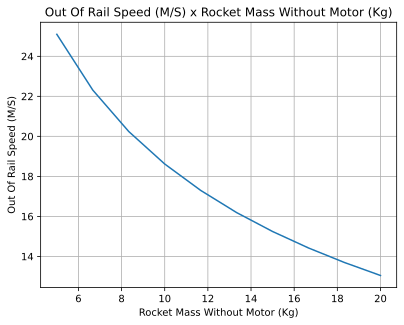

'Function from R1 to R1 : (Rocket Mass without motor (kg)) → (Out of Rail Speed (m/s))'

In [18]:
from rocketpy.utilities import liftoff_speed_by_mass

liftoff_speed_by_mass(flight=test_flight, min_mass=5, max_mass=20, points=10, plot=True)

### Estabilidade dinâmica versus envergadura

A **margem estática** num instante não descreve sozinha o amortecimento das oscilações. O experimento numérico abaixo **escala a envergadura das aletas**, reavalia a margem no trilho e no fim do voo, e calcula o **nível de estabilidade dinâmica** — ligação entre geometria, inércia e modo de curto período.


Simulando foguete com margem estática de 1.327->1.479 c
Current Simulation Time: 3.4119 s
>>> Simulation Completed at Time: 3.4088 s
Simulando foguete com margem estática de -0.474->-0.323 c
Current Simulation Time: 3.3591 s
>>> Simulation Completed at Time: 3.3556 s
Simulando foguete com margem estática de -2.276->-2.125 c
Current Simulation Time: 3.3307 s
>>> Simulation Completed at Time: 3.3292 s
Simulando foguete com margem estática de -4.078->-3.926 c
Current Simulation Time: 3.3427 s
>>> Simulation Completed at Time: 3.3353 s
Simulando foguete com margem estática de -5.879->-5.728 c
Current Simulation Time: 3.3594 s
>>> Simulation Completed at Time: 3.3569 s


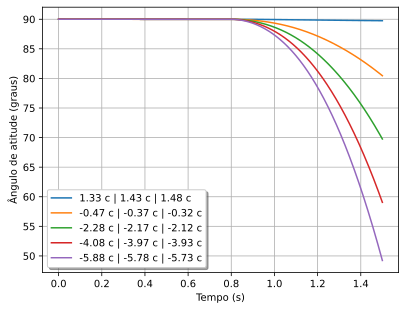

In [19]:
# Classe auxiliar
import copy

from rocketpy import Function

# Preparar uma cópia do foguete
FalconOneRocket2 = copy.deepcopy(FalconOneRocket)

# Preparar a classe Environment
custom_env = Environment()
custom_env.set_atmospheric_model(type="custom_atmosphere", wind_v=-5)

# Simular diferentes margens estáticas variando a posição das aletas
simulation_results = []

for factor in [-0.5, -0.2, 0.1, 0.4, 0.7]:
    # Modificar conjunto de aletas removendo o anterior e adicionando um novo
    FalconOneRocket2.aerodynamic_surfaces.pop(-1)

    fin_set = FalconOneRocket2.add_trapezoidal_fins(
        n=4,
        root_chord=0.120,
        tip_chord=0.040,
        span=0.100,
        position=-1.04956 * factor,
    )
    # Simular
    print(
        "Simulando foguete com margem estática de {:1.3f}->{:1.3f} c".format(
            FalconOneRocket2.static_margin(0),
            FalconOneRocket2.static_margin(FalconOneRocket2.motor.burn_out_time),
        )
    )
    test_flight = Flight(
        rocket=FalconOneRocket2,
        environment=custom_env,
        rail_length=5.2,
        inclination=90,
        heading=0,
        max_time_step=0.01,
        max_time=5,
        terminate_on_apogee=True,
        verbose=True,
    )
    # Armazenar resultados
    static_margin_at_ignition = FalconOneRocket2.static_margin(0)
    static_margin_at_out_of_rail = FalconOneRocket2.static_margin(test_flight.out_of_rail_time)
    static_margin_at_steady_state = FalconOneRocket2.static_margin(test_flight.t_final)
    simulation_results += [
        (
            test_flight.attitude_angle,
            "{:1.2f} c | {:1.2f} c | {:1.2f} c".format(
                static_margin_at_ignition,
                static_margin_at_out_of_rail,
                static_margin_at_steady_state,
            ),
        )
    ]

Function.compare_plots(
    simulation_results,
    lower=0,
    upper=1.5,
    xlabel="Tempo (s)",
    ylabel="Ângulo de atitude (graus)",
)

### Frequência característica ao sair do trilho

Logo após a **saída do trilho**, o modo rígido–corpo que domina o pitch/yaw tem uma **frequência característica** associada à rigidez aerodinâmica e à inércia. O bloco abaixo extrai explicitamente esse espectro (complementar ao que já aparece em `all_info()`), com escolha fina das séries exibidas.


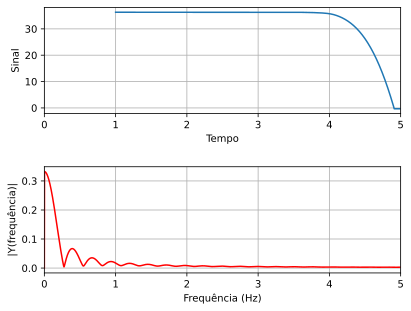

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Simular os primeiros 5 segundos de voo
flight = Flight(
    rocket=FalconOneRocket,
    environment=env,
    rail_length=5.2,
    inclination=90,
    heading=0,
    max_time_step=0.01,
    max_time=5,
)

# Realizar uma análise de Fourier
Fs = 100.0
# taxa de amostragem
Ts = 1.0 / Fs
# intervalo de amostragem
t = np.arange(1, 400, Ts)  # vetor de tempo
ff = 5
# frequência do sinal
y = flight.attitude_angle(t) - np.mean(flight.attitude_angle(t))
n = len(y)  # comprimento do sinal
k = np.arange(n)
T = n / Fs
frq = k / T  # faixa de frequência de dois lados
frq = frq[range(n // 2)]  # faixa de frequência de um lado
Y = np.fft.fft(y) / n  # cálculo e normalização da FFT
Y = Y[range(n // 2)]

# Criar o gráfico
fig, ax = plt.subplots(2, 1)
ax[0].plot(t, y)
ax[0].set_xlabel("Tempo")
ax[0].set_ylabel("Sinal")
ax[0].set_xlim((0, 5))
ax[0].grid()
ax[1].plot(frq, abs(Y), "r")  # plotando o espectro
ax[1].set_xlabel("Frequência (Hz)")
ax[1].set_ylabel("|Y(frequência)|")
ax[1].set_xlim((0, 5))
ax[1].grid()
plt.subplots_adjust(hspace=0.5)
plt.show()

## Exportacao automatica de resultados por setor

A celula abaixo gera uma pasta `Resultados_Simulacao_YYYY-MM-DD_HHhMM/` (com timestamp) contendo subpastas para cada setor da equipe. Cada execucao cria uma pasta nova, sem sobrescrever resultados anteriores.

**Setores:** Motor e Propulsão · Estruturas e Aerodinâmica · Trajetória · Aviônica e Payload · Recuperação

Cada setor recebe graficos (`.png`) e dados (`.txt` resumo + `.csv` series temporais). Graficos compartilhados entre setores aparecem em cada pasta correspondente.

In [21]:
import os
import csv
import copy
import shutil
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as _dt
from rocketpy.utilities import apogee_by_mass, liftoff_speed_by_mass
from rocketpy import Function, Environment, Flight

# =================================================================
# CONFIGURACAO
# =================================================================
_timestamp = _dt.now().strftime("%Y-%m-%d_%Hh%M")
PASTA_RAIZ = os.path.join(os.getcwd(), f"Resultados_Simulacao_{_timestamp}")

voo         = main_flight
motor_obj   = FalconOne
foguete_obj = FalconOneRocket
ambiente_obj = env

SETORES = [
    "Motor_e_Propulsao",
    "Estruturas_e_Aerodinamica",
    "Trajetoria",
    "Avionica_e_Payload",
    "Recuperacao",
]

for s in SETORES:
    os.makedirs(os.path.join(PASTA_RAIZ, s, "graficos"), exist_ok=True)
    os.makedirs(os.path.join(PASTA_RAIZ, s, "dados"), exist_ok=True)

def c(setor, nome):
    return os.path.join(PASTA_RAIZ, setor, "graficos", nome)

def cd(setor, nome):
    return os.path.join(PASTA_RAIZ, setor, "dados", nome)

_show_orig = plt.show

def salvar(metodo, *destinos):
    """Salva grafico no primeiro destino, copia para os demais."""
    plt.close("all")
    plt.show = lambda *a, **kw: None
    primeiro = destinos[0]
    try:
        try:
            metodo(filename=primeiro)
        except TypeError:
            metodo()
            nums = plt.get_fignums()
            if nums:
                plt.figure(nums[0]).savefig(primeiro, dpi=200, bbox_inches="tight")
    except Exception as e:
        print(f"    [aviso] {os.path.basename(primeiro)}: {e}")
    finally:
        plt.show = _show_orig
    plt.close("all")
    if os.path.exists(primeiro):
        for d in destinos[1:]:
            shutil.copy2(primeiro, d)

plt.ioff()
t_voo = np.arange(voo.t_initial, voo.t_final, 0.05)
elev = getattr(ambiente_obj, "elevation", 0) or 0

# =================================================================
# GRAFICOS — seguindo a divisao por setor
# =================================================================
print("[1/9] Ambiente (Trajetoria)...")
alt = np.linspace(0, 10000, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot([float(ambiente_obj.wind_speed(h)) for h in alt], alt, "b-", lw=2)
ax1.set_xlabel("Velocidade do Vento (m/s)"); ax1.set_ylabel("Altitude (m)")
ax1.set_title("Velocidade do Vento"); ax1.grid(True, alpha=0.3)
ax2.plot([float(ambiente_obj.wind_direction(h)) for h in alt], alt, "r-", lw=2)
ax2.set_xlabel("Direção do Vento (°)"); ax2.set_ylabel("Altitude (m)")
ax2.set_title("Direção do Vento"); ax2.grid(True, alpha=0.3)
fig.suptitle("Perfil de Vento", fontsize=14, fontweight="bold"); fig.tight_layout()
fig.savefig(c("Trajetoria", "vento_velocidade_direcao.png"), dpi=200, bbox_inches="tight")
plt.close("all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot([float(ambiente_obj.speed_of_sound(h)) for h in alt], alt, "g-", lw=2)
ax1.set_xlabel("Velocidade do Som (m/s)"); ax1.set_ylabel("Altitude (m)")
ax1.set_title("Velocidade do Som"); ax1.grid(True, alpha=0.3)
ax2.plot([float(ambiente_obj.density(h)) for h in alt], alt, "m-", lw=2)
ax2.set_xlabel("Densidade (kg/m³)"); ax2.set_ylabel("Altitude (m)")
ax2.set_title("Densidade do Ar"); ax2.grid(True, alpha=0.3)
fig.suptitle("Velocidade do Som e Densidade", fontsize=14, fontweight="bold"); fig.tight_layout()
fig.savefig(c("Trajetoria", "som_densidade.png"), dpi=200, bbox_inches="tight")
plt.close("all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot([float(ambiente_obj.pressure(h)) for h in alt], alt, "c-", lw=2)
ax1.set_xlabel("Pressão (Pa)"); ax1.set_ylabel("Altitude (m)")
ax1.set_title("Pressão Atmosférica"); ax1.grid(True, alpha=0.3)
ax2.plot([float(ambiente_obj.temperature(h)) for h in alt], alt, "r-", lw=2)
ax2.set_xlabel("Temperatura (K)"); ax2.set_ylabel("Altitude (m)")
ax2.set_title("Temperatura"); ax2.grid(True, alpha=0.3)
fig.suptitle("Pressão e Temperatura", fontsize=14, fontweight="bold"); fig.tight_layout()
fig.savefig(c("Trajetoria", "pressao_temperatura.png"), dpi=200, bbox_inches="tight")
plt.close("all")

# -----------------------------------------------------------------
print("[2/9] Motor e Foguete...")

salvar(motor_obj.plots.thrust,
       c("Motor_e_Propulsao", "empuxo_tempo.png"))

salvar(foguete_obj.plots.draw,
       c("Estruturas_e_Aerodinamica", "repr_foguete.png"),
       c("Motor_e_Propulsao", "repr_foguete.png"))

salvar(motor_obj.plots.draw,
       c("Motor_e_Propulsao", "repr_motor.png"))

salvar(foguete_obj.plots.total_mass,
       c("Estruturas_e_Aerodinamica", "massa_total.png"),
       c("Motor_e_Propulsao", "massa_total.png"))

salvar(foguete_obj.plots.reduced_mass,
       c("Estruturas_e_Aerodinamica", "massa_reduzida.png"),
       c("Motor_e_Propulsao", "massa_reduzida.png"))

# -----------------------------------------------------------------
print("[3/9] Aerodinamica e Estabilidade...")

salvar(foguete_obj.plots.drag_curves,
       c("Estruturas_e_Aerodinamica", "arrasto_mach.png"))

salvar(foguete_obj.plots.static_margin,
       c("Estruturas_e_Aerodinamica", "margem_estatica_2d.png"))

salvar(foguete_obj.plots.stability_margin,
       c("Estruturas_e_Aerodinamica", "estabilidade_margem_3d.png"))

salvar(foguete_obj.plots.thrust_to_weight,
       c("Estruturas_e_Aerodinamica", "empuxo_peso.png"),
       c("Motor_e_Propulsao", "empuxo_peso.png"))

# -----------------------------------------------------------------
print("[4/9] Voo — cinematica e forcas...")

salvar(voo.plots.trajectory_3d,
       c("Trajetoria", "trajetoria_3d.png"),
       c("Recuperacao", "trajetoria_3d.png"))

salvar(voo.plots.linear_kinematics_data,
       c("Estruturas_e_Aerodinamica", "velocidades_aceleracoes.png"))

salvar(voo.plots.flight_path_angle_data,
       c("Recuperacao", "caminho_voo_angulo.png"),
       c("Trajetoria", "caminho_voo_angulo.png"))

salvar(voo.plots.attitude_data,
       c("Motor_e_Propulsao", "euler_angulos.png"),
       c("Estruturas_e_Aerodinamica", "euler_angulos.png"),
       c("Recuperacao", "euler_angulos.png"))

salvar(voo.plots.angular_kinematics_data,
       c("Estruturas_e_Aerodinamica", "vel_angular_aceleracao.png"))

salvar(voo.plots.aerodynamic_forces,
       c("Estruturas_e_Aerodinamica", "forcas_aerodinamicas.png"))

salvar(voo.plots.energy_data,
       c("Estruturas_e_Aerodinamica", "energia.png"))

salvar(voo.plots.fluid_mechanics_data,
       c("Estruturas_e_Aerodinamica", "mecanica_fluidos.png"),
       c("Avionica_e_Payload", "mecanica_fluidos.png"))

salvar(voo.plots.stability_and_control_data,
       c("Estruturas_e_Aerodinamica", "estabilidade_controle.png"))

# -----------------------------------------------------------------
print("[5/9] Pressao e Paraquedas...")

salvar(voo.plots.pressure_rocket_altitude,
       c("Avionica_e_Payload", "pressao_altitude.png"))

plt.close("all")
plt.show = lambda *a, **kw: None
try:
    voo.plots.pressure_signals()
except Exception as e:
    print(f"    [aviso] pressure_signals: {e}")
plt.show = _show_orig
nums = plt.get_fignums()
if len(nums) >= 3:
    plt.figure(nums[0]).savefig(
        c("Recuperacao", "escalar_x.png"), dpi=200, bbox_inches="tight")
    plt.figure(nums[1]).savefig(
        c("Avionica_e_Payload", "pressao_nariz.png"), dpi=200, bbox_inches="tight")
    shutil.copy2(c("Avionica_e_Payload", "pressao_nariz.png"),
                 c("Recuperacao", "pressao_nariz.png"))
    plt.figure(nums[2]).savefig(
        c("Recuperacao", "pressao_sem_nariz.png"), dpi=200, bbox_inches="tight")
plt.close("all")

# -----------------------------------------------------------------
print("[6/9] Sensibilidades (pode levar ~1 min)...")

func_apogee = apogee_by_mass(flight=voo, min_mass=5, max_mass=20, points=10, plot=False)
fig, ax = plt.subplots(figsize=(10, 6))
src = np.array(func_apogee.source)
ax.plot(src[:, 0], src[:, 1], "o-", linewidth=2, markersize=6, color="tab:blue")
ax.set_xlabel("Massa do foguete sem motor (kg)")
ax.set_ylabel("Apogeu AGL (m)")
ax.set_title("Apogeu vs Massa do Foguete")
ax.grid(True, alpha=0.3); fig.tight_layout()
fig.savefig(c("Estruturas_e_Aerodinamica", "apogeu_vs_massa.png"), dpi=200, bbox_inches="tight")
plt.close("all")
shutil.copy2(c("Estruturas_e_Aerodinamica", "apogeu_vs_massa.png"),
             c("Motor_e_Propulsao", "apogeu_vs_massa.png"))

func_speed = liftoff_speed_by_mass(flight=voo, min_mass=5, max_mass=20, points=10, plot=False)
fig, ax = plt.subplots(figsize=(10, 6))
src = np.array(func_speed.source)
ax.plot(src[:, 0], src[:, 1], "o-", linewidth=2, markersize=6, color="tab:green")
ax.set_xlabel("Massa do foguete sem motor (kg)")
ax.set_ylabel("Velocidade na saida do trilho (m/s)")
ax.set_title("Velocidade no Trilho vs Massa do Foguete")
ax.grid(True, alpha=0.3); fig.tight_layout()
fig.savefig(c("Trajetoria", "velocidade_trilho_vs_massa.png"), dpi=200, bbox_inches="tight")
plt.close("all")
shutil.copy2(c("Trajetoria", "velocidade_trilho_vs_massa.png"),
             c("Motor_e_Propulsao", "velocidade_trilho_vs_massa.png"))

# -----------------------------------------------------------------
print("[7/9] Estabilidade dinamica (angulo de atitude)...")

try:
    _sim_results = simulation_results
except NameError:
    _sim_results = None

if _sim_results is None:
    FalconOneRocket2 = copy.deepcopy(foguete_obj)
    custom_env2 = Environment()
    custom_env2.set_atmospheric_model(type="custom_atmosphere", wind_v=-5)
    _sim_results = []
    for factor in [-0.5, -0.2, 0.1, 0.4, 0.7]:
        FalconOneRocket2.aerodynamic_surfaces.pop(-1)
        FalconOneRocket2.add_trapezoidal_fins(
            n=4, root_chord=0.120, tip_chord=0.040, span=0.100,
            position=-1.04956 * factor,
        )
        sim = Flight(
            rocket=FalconOneRocket2, environment=custom_env2,
            rail_length=5.2, inclination=90, heading=0,
            max_time_step=0.01, max_time=5,
            terminate_on_apogee=True, verbose=False,
        )
        sm_i = FalconOneRocket2.static_margin(0)
        sm_o = FalconOneRocket2.static_margin(sim.out_of_rail_time)
        sm_f = FalconOneRocket2.static_margin(sim.t_final)
        _sim_results.append((
            sim.attitude_angle,
            f"{sm_i:1.2f} c | {sm_o:1.2f} c | {sm_f:1.2f} c",
        ))

plt.close("all")
plt.show = lambda *a, **kw: None
Function.compare_plots(
    _sim_results, lower=0, upper=1.5,
    xlabel="Tempo (s)", ylabel="Ângulo de atitude (graus)",
)
plt.show = _show_orig
nums = plt.get_fignums()
if nums:
    plt.figure(nums[0]).savefig(
        os.path.join(PASTA_RAIZ, "angulo_atitude_tempo.png"),
        dpi=200, bbox_inches="tight")
plt.close("all")

# -----------------------------------------------------------------
print("[8/9] Frequencia caracteristica (Estruturas)...")

flight_fft = Flight(
    rocket=foguete_obj, environment=ambiente_obj,
    rail_length=5.2, inclination=90, heading=0,
    max_time_step=0.01, max_time=5, verbose=False,
)

Fs_fft = 100.0
t_fft = np.arange(1, 400, 1.0 / Fs_fft)
y_fft = flight_fft.attitude_angle(t_fft) - np.mean(flight_fft.attitude_angle(t_fft))
n_fft = len(y_fft)
T_fft = n_fft / Fs_fft
frq = np.arange(n_fft) / T_fft
frq = frq[: n_fft // 2]
Y_fft = np.fft.fft(y_fft) / n_fft
Y_fft = Y_fft[: n_fft // 2]

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(t_fft, y_fft); ax[0].set_xlabel("Tempo (s)"); ax[0].set_ylabel("Sinal")
ax[0].set_xlim((0, 5)); ax[0].grid(True, alpha=0.3)
ax[1].plot(frq, np.abs(Y_fft), "r"); ax[1].set_xlabel("Frequência (Hz)")
ax[1].set_ylabel("|Y(frequência)|"); ax[1].set_xlim((0, 5)); ax[1].grid(True, alpha=0.3)
fig.suptitle("Frequência Característica ao Sair do Trilho", fontsize=14, fontweight="bold")
plt.subplots_adjust(hspace=0.5)
fig.savefig(c("Estruturas_e_Aerodinamica", "freq_caracteristica.png"),
            dpi=200, bbox_inches="tight")
plt.close("all")

# =================================================================
# DADOS (resumos .txt e series .csv)
# =================================================================
print("[9/9] Dados por setor...")

bt = motor_obj.burn_out_time

with open(cd("Motor_e_Propulsao", "resumo_motor.txt"), "w", encoding="utf-8") as f:
    f.write("=" * 60 + "\n  RESUMO DO MOTOR - FALCON ONE\n" + "=" * 60 + "\n\n")
    f.write(f"Tempo de queima:              {bt:.4f} s\n")
    f.write(f"Impulso total:                {motor_obj.total_impulse:.2f} N.s\n")
    f.write(f"Empuxo medio:                 {motor_obj.average_thrust:.2f} N\n")
    f.write(f"Massa seca:                   {motor_obj.dry_mass:.3f} kg\n")
    f.write(f"Massa de propelente:          {motor_obj.propellant_initial_mass:.3f} kg\n")
    f.write(f"Razao de massa estrutural:    {motor_obj.structural_mass_ratio:.3f}\n")
    f.write(f"Numero de graos:              {motor_obj.grain_number}\n")
    f.write(f"Raio externo do grao:         {motor_obj.grain_outer_radius*1000:.2f} mm\n")
    f.write(f"Raio interno inicial:         {motor_obj.grain_initial_inner_radius*1000:.2f} mm\n")
    f.write(f"Altura inicial do grao:       {motor_obj.grain_initial_height*1000:.2f} mm\n")
    f.write(f"Raio da garganta:             {motor_obj.throat_radius*1000:.2f} mm\n")
    f.write(f"Raio do bocal:                {motor_obj.nozzle_radius*1000:.2f} mm\n")

t_m = np.arange(0, bt + 0.01, 0.01)
with open(cd("Motor_e_Propulsao", "series_motor.csv"), "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["tempo_s", "empuxo_N", "massa_total_kg",
                "massa_propelente_kg", "vazao_massica_kg_s"])
    for ti in t_m:
        w.writerow([f"{ti:.4f}", f"{float(motor_obj.thrust(ti)):.4f}",
                     f"{float(motor_obj.total_mass(ti)):.4f}",
                     f"{float(motor_obj.propellant_mass(ti)):.4f}",
                     f"{float(motor_obj.mass_flow_rate(ti)):.6f}"])

with open(cd("Estruturas_e_Aerodinamica", "resumo_estruturas.txt"), "w", encoding="utf-8") as f:
    f.write("=" * 60 + "\n  RESUMO - ESTRUTURAS E AERODINAMICA\n" + "=" * 60 + "\n\n")
    f.write("--- Cargas Maximas ---\n")
    f.write(f"Aceleracao max (motor ON):     {voo.max_acceleration_power_on:.2f} m/s2"
            f" ({voo.max_acceleration_power_on/9.81:.2f} g)"
            f" em t = {voo.max_acceleration_power_on_time:.3f} s\n")
    f.write(f"Aceleracao max (motor OFF):    {voo.max_acceleration_power_off:.2f} m/s2"
            f" ({voo.max_acceleration_power_off/9.81:.2f} g)"
            f" em t = {voo.max_acceleration_power_off_time:.3f} s\n")
    f.write(f"Pressao dinamica maxima:       {voo.max_dynamic_pressure:.2f} Pa"
            f" em t = {voo.max_dynamic_pressure_time:.3f} s\n")
    f.write(f"Mach maximo:                   {voo.max_mach_number:.4f}"
            f" em t = {voo.max_mach_number_time:.3f} s\n")
    f.write(f"Reynolds maximo:               {voo.max_reynolds_number:.0f}"
            f" em t = {voo.max_reynolds_number_time:.3f} s\n")
    f.write(f"\n--- Estabilidade ---\n")
    f.write(f"Margem estatica inicial:       {voo.initial_stability_margin:.3f} cal\n")
    f.write(f"Margem estatica maxima:        {voo.max_stability_margin:.3f} cal"
            f" em t = {voo.max_stability_margin_time:.3f} s\n")
    f.write(f"Margem estatica minima:        {voo.min_stability_margin:.3f} cal"
            f" em t = {voo.min_stability_margin_time:.3f} s\n")
    f.write(f"\n--- Geometria ---\n")
    f.write(f"Raio maximo:                   {foguete_obj.radius*1000:.2f} mm\n")
    f.write(f"Area frontal:                  {np.pi * foguete_obj.radius**2 * 1e4:.2f} cm2\n")
    f.write(f"Massa sem motor:               {foguete_obj.mass:.3f} kg\n")

with open(cd("Estruturas_e_Aerodinamica", "series_aerodinamica.csv"), "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["tempo_s", "arrasto_N", "sustentacao_N", "momento_fletor_Nm",
                "pressao_dinamica_Pa", "mach", "reynolds", "angulo_ataque",
                "margem_estatica_cal"])
    for ti in t_voo:
        try:
            w.writerow([
                f"{ti:.4f}", f"{float(voo.aerodynamic_drag(ti)):.4f}",
                f"{float(voo.aerodynamic_lift(ti)):.4f}",
                f"{float(voo.aerodynamic_bending_moment(ti)):.4f}",
                f"{float(voo.dynamic_pressure(ti)):.2f}",
                f"{float(voo.mach_number(ti)):.6f}",
                f"{float(voo.reynolds_number(ti)):.0f}",
                f"{float(voo.angle_of_attack(ti)):.4f}",
                f"{float(voo.stability_margin(ti)):.4f}",
            ])
        except Exception:
            pass

try:
    voo.export_kml(
        file_name=cd("Trajetoria", "trajetoria.kml"),
        extrude=True, altitude_mode="relative_to_ground",
    )
except Exception:
    pass

with open(cd("Trajetoria", "resumo_trajetoria.txt"), "w", encoding="utf-8") as f:
    f.write("=" * 60 + "\n  RESUMO - TRAJETORIA\n" + "=" * 60 + "\n\n")
    f.write("--- Saida do Trilho ---\n")
    f.write(f"Tempo:                         {voo.out_of_rail_time:.3f} s\n")
    f.write(f"Velocidade:                    {voo.out_of_rail_velocity:.2f} m/s\n")
    f.write(f"\n--- Apogeu ---\n")
    f.write(f"Tempo:                         {voo.apogee_time:.3f} s\n")
    f.write(f"Altitude (ASL):                {voo.apogee:.2f} m\n")
    f.write(f"Altitude (AGL):                {voo.apogee - elev:.2f} m\n")
    f.write(f"Velocidade freestream:         {voo.apogee_freestream_speed:.2f} m/s\n")
    f.write(f"\n--- Velocidade Maxima ---\n")
    f.write(f"Velocidade:                    {voo.max_speed:.2f} m/s\n")
    f.write(f"Tempo:                         {voo.max_speed_time:.3f} s\n")
    f.write(f"\n--- Impacto ---\n")
    f.write(f"Tempo total de voo:            {voo.t_final:.2f} s\n")
    f.write(f"Velocidade vertical:           {voo.impact_velocity:.2f} m/s\n")
    f.write(f"Posicao X:                     {voo.x_impact:.2f} m\n")
    f.write(f"Posicao Y:                     {voo.y_impact:.2f} m\n")
    drift = np.sqrt(voo.x_impact**2 + voo.y_impact**2)
    f.write(f"Distancia de deriva:           {drift:.2f} m\n")

with open(cd("Trajetoria", "series_trajetoria.csv"), "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["tempo_s", "altitude_AGL_m", "altitude_ASL_m", "velocidade_m_s",
                "vx_m_s", "vy_m_s", "vz_m_s", "aceleracao_m_s2",
                "x_m", "y_m", "latitude", "longitude"])
    for ti in t_voo:
        try:
            w.writerow([
                f"{ti:.4f}", f"{float(voo.altitude(ti)):.2f}",
                f"{float(voo.z(ti)):.2f}", f"{float(voo.speed(ti)):.4f}",
                f"{float(voo.vx(ti)):.4f}", f"{float(voo.vy(ti)):.4f}",
                f"{float(voo.vz(ti)):.4f}", f"{float(voo.acceleration(ti)):.4f}",
                f"{float(voo.x(ti)):.4f}", f"{float(voo.y(ti)):.4f}",
                f"{float(voo.latitude(ti)):.8f}", f"{float(voo.longitude(ti)):.8f}",
            ])
        except Exception:
            pass

with open(cd("Avionica_e_Payload", "resumo_avionica_payload.txt"), "w", encoding="utf-8") as f:
    f.write("=" * 60 + "\n  RESUMO - AVIONICA E PAYLOAD\n" + "=" * 60 + "\n\n")
    f.write("--- Eventos de Voo ---\n")
    f.write(f"Saida do trilho:               t = {voo.out_of_rail_time:.3f} s\n")
    f.write(f"Velocidade na saida:           {voo.out_of_rail_velocity:.2f} m/s\n")
    f.write(f"Apogeu:                        t = {voo.apogee_time:.3f} s\n")
    f.write(f"Altitude no apogeu (AGL):      {voo.apogee - elev:.2f} m\n")
    f.write(f"Acionamento do paraquedas:     t ~ {voo.apogee_time:.3f} s (trigger: apogee)\n")
    for chute in foguete_obj.parachutes:
        f.write(f"  Paraquedas: {chute.name}, lag = {chute.lag:.2f} s\n")
    f.write(f"Impacto:                       t = {voo.t_final:.2f} s\n")
    f.write(f"\n--- Dados de Sensores ---\n")
    f.write(f"Pressao na superficie:         {float(ambiente_obj.pressure(0)):.2f} Pa\n")
    f.write(f"Pressao no apogeu:             {float(ambiente_obj.pressure(voo.apogee)):.2f} Pa\n")
    f.write(f"Duracao total do voo:          {voo.t_final:.2f} s\n")
    f.write(f"\n--- Ambiente de Payload ---\n")
    f.write(f"Aceleracao maxima (motor ON):  {voo.max_acceleration_power_on:.2f} m/s2"
            f" ({voo.max_acceleration_power_on/9.81:.2f} g)\n")
    f.write(f"Aceleracao maxima (total):     {voo.max_acceleration:.2f} m/s2"
            f" ({voo.max_acceleration/9.81:.2f} g)\n")
    f.write(f"Pressao dinamica maxima:       {voo.max_dynamic_pressure:.2f} Pa\n")
    f.write(f"Velocidade maxima:             {voo.max_speed:.2f} m/s\n")
    f.write(f"Mach maximo:                   {voo.max_mach_number:.4f}\n")

with open(cd("Avionica_e_Payload", "series_avionica.csv"), "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["tempo_s", "phi_rad", "theta_rad", "psi_rad",
                "w1_rad_s", "w2_rad_s", "w3_rad_s",
                "angulo_atitude", "pressao_Pa"])
    for ti in t_voo:
        try:
            w.writerow([
                f"{ti:.4f}",
                f"{float(voo.phi(ti)):.6f}", f"{float(voo.theta(ti)):.6f}",
                f"{float(voo.psi(ti)):.6f}",
                f"{float(voo.w1(ti)):.6f}", f"{float(voo.w2(ti)):.6f}",
                f"{float(voo.w3(ti)):.6f}",
                f"{float(voo.attitude_angle(ti)):.4f}",
                f"{float(voo.pressure(ti)):.2f}",
            ])
        except Exception:
            pass

chute = foguete_obj.parachutes[0] if foguete_obj.parachutes else None
with open(cd("Recuperacao", "resumo_recuperacao.txt"), "w", encoding="utf-8") as f:
    f.write("=" * 60 + "\n  RESUMO - RECUPERACAO\n" + "=" * 60 + "\n\n")
    if chute:
        f.write("--- Paraquedas ---\n")
        f.write(f"Nome:                          {chute.name}\n")
        f.write(f"Cd*S:                          {chute.cd_s:.4f} m2\n")
        f.write(f"Trigger:                       apogee\n")
        f.write(f"Lag (atraso de ejecao):        {chute.lag:.2f} s\n")
        f.write(f"Taxa de amostragem:            {chute.sampling_rate} Hz\n\n")
    f.write("--- Apogeu (inicio da descida) ---\n")
    f.write(f"Tempo:                         {voo.apogee_time:.3f} s\n")
    f.write(f"Altitude (AGL):                {voo.apogee - elev:.2f} m\n\n")
    f.write("--- Impacto ---\n")
    f.write(f"Velocidade de impacto:         {abs(voo.impact_velocity):.2f} m/s\n")
    f.write(f"Tempo de descida:              {voo.t_final - voo.apogee_time:.2f} s\n")
    drift = np.sqrt(voo.x_impact**2 + voo.y_impact**2)
    f.write(f"Deriva total:                  {drift:.2f} m\n")
    f.write(f"Posicao X no impacto:          {voo.x_impact:.2f} m\n")
    f.write(f"Posicao Y no impacto:          {voo.y_impact:.2f} m\n")

t_desc = np.arange(voo.apogee_time, voo.t_final, 0.5)
with open(cd("Recuperacao", "series_descida.csv"), "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["tempo_s", "altitude_AGL_m", "velocidade_m_s",
                "vz_m_s", "x_m", "y_m"])
    for ti in t_desc:
        try:
            w.writerow([
                f"{ti:.4f}", f"{float(voo.altitude(ti)):.2f}",
                f"{float(voo.speed(ti)):.4f}", f"{float(voo.vz(ti)):.4f}",
                f"{float(voo.x(ti)):.4f}", f"{float(voo.y(ti)):.4f}",
            ])
        except Exception:
            pass

# =================================================================
# RESUMO FINAL
# =================================================================
plt.ion()
print(f"\nExportacao concluida!")
print(f"Pasta: {PASTA_RAIZ}\n")
for s in SETORES:
    g = os.path.join(PASTA_RAIZ, s, "graficos")
    d = os.path.join(PASTA_RAIZ, s, "dados")
    ng = len(os.listdir(g)) if os.path.isdir(g) else 0
    nd = len(os.listdir(d)) if os.path.isdir(d) else 0
    print(f"  {s}: {ng} graficos, {nd} arquivos de dados")
raiz_pngs = [f for f in os.listdir(PASTA_RAIZ) if f.endswith(".png")]
if raiz_pngs:
    print(f"  (raiz): {len(raiz_pngs)} graficos sem setor")

[1/9] Ambiente (Trajetoria)...
[2/9] Motor e Foguete...
[3/9] Aerodinamica e Estabilidade...
[4/9] Voo — cinematica e forcas...
[5/9] Pressao e Paraquedas...

Parachute:  ParaQuedas
[6/9] Sensibilidades (pode levar ~1 min)...
[7/9] Estabilidade dinamica (angulo de atitude)...
[8/9] Frequencia caracteristica (Estruturas)...
[9/9] Dados por setor...
File  /home/colombs/Documentos/falcon2/RPy-Falcon6/Resultados_Simulacao_2026-06-08_11h45/Trajetoria/dados/trajetoria.kml  saved with success!


/tmp/ipykernel_14271/759723757.py:390: DeprecationWarning: Moved to FlightDataExporter.export_kml() and will be removed in v1.12.0. Use `rocketpy.simulation.flight_data_exporter.FlightDataExporter.export_kml` instead.
  voo.export_kml(



Exportacao concluida!
Pasta: /home/colombs/Documentos/falcon2/RPy-Falcon6/Resultados_Simulacao_2026-06-08_11h45

  Motor_e_Propulsao: 9 graficos, 2 arquivos de dados
  Estruturas_e_Aerodinamica: 16 graficos, 2 arquivos de dados
  Trajetoria: 6 graficos, 3 arquivos de dados
  Avionica_e_Payload: 3 graficos, 2 arquivos de dados
  Recuperacao: 6 graficos, 2 arquivos de dados
  (raiz): 1 graficos sem setor


In [22]:
# =================================================================
# GERACAO DOS RELATORIOS PDF
# =================================================================
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.image import imread

plt.ioff()
drift = np.sqrt(voo.x_impact**2 + voo.y_impact**2)


def pagina_texto(linhas, titulo=None):
    """Cria uma pagina de texto puro como figura matplotlib."""
    fig = plt.figure(figsize=(11.69, 8.27))
    fig.patch.set_facecolor("white")
    y = 0.92
    if titulo:
        fig.text(0.5, y, titulo, ha="center", va="top",
                 fontsize=20, fontweight="bold")
        y -= 0.06
    for linha in linhas:
        if linha.startswith("---"):
            fig.text(0.08, y, linha.replace("---", "").strip(),
                     fontsize=13, fontweight="bold")
        else:
            fig.text(0.08, y, linha, fontsize=10, family="monospace")
        y -= 0.028
        if y < 0.04:
            break
    return fig


def pagina_imagem(png_path):
    """Cria uma pagina com a imagem PNG embarcada."""
    img = imread(png_path)
    h, w = img.shape[:2]
    aspect = w / h
    fig_w, fig_h = 11.69, 8.27
    fig = plt.figure(figsize=(fig_w, fig_h))
    fig.patch.set_facecolor("white")
    ax = fig.add_axes([0.02, 0.02, 0.96, 0.96])
    ax.imshow(img, aspect="equal")
    ax.axis("off")
    return fig


def ler_resumo(path):
    """Le um arquivo .txt e retorna as linhas."""
    if not os.path.exists(path):
        return []
    with open(path, "r", encoding="utf-8") as f:
        return [l.rstrip() for l in f.readlines()]


def gerar_pdf_setor(setor_dir, nome_setor, pdf_path):
    """Gera PDF com resumo de dados + graficos do setor."""
    dados_dir = os.path.join(setor_dir, "dados")
    graf_dir = os.path.join(setor_dir, "graficos")

    with PdfPages(pdf_path) as pdf:
        capa = pagina_texto([
            "",
            f"Data da simulacao: {_timestamp}",
            f"Apogeu: {voo.apogee - elev:.2f} m AGL",
            f"Velocidade maxima: {voo.max_speed:.2f} m/s (Mach {voo.max_mach_number:.3f})",
            f"Tempo total de voo: {voo.t_final:.2f} s",
            f"Velocidade de impacto: {abs(voo.impact_velocity):.2f} m/s",
        ], titulo=f"Relatorio — {nome_setor}")
        pdf.savefig(capa); plt.close(capa)

        for txt in sorted(os.listdir(dados_dir)):
            if txt.endswith(".txt"):
                linhas = ler_resumo(os.path.join(dados_dir, txt))
                if linhas:
                    fig = pagina_texto(linhas)
                    pdf.savefig(fig); plt.close(fig)

        for png in sorted(os.listdir(graf_dir)):
            if png.endswith(".png"):
                fig = pagina_imagem(os.path.join(graf_dir, png))
                pdf.savefig(fig); plt.close(fig)

    plt.close("all")


print("\nGerando relatorios PDF...")

NOMES_SETORES = {
    "Motor_e_Propulsao": "Motor e Propulsao",
    "Estruturas_e_Aerodinamica": "Estruturas e Aerodinamica",
    "Trajetoria": "Trajetoria",
    "Avionica_e_Payload": "Avionica e Payload",
    "Recuperacao": "Recuperacao",
}

for setor_key in SETORES:
    nome = NOMES_SETORES[setor_key]
    setor_dir = os.path.join(PASTA_RAIZ, setor_key)
    pdf_path = os.path.join(setor_dir, f"Relatorio_{setor_key}.pdf")
    gerar_pdf_setor(setor_dir, nome, pdf_path)
    size_kb = os.path.getsize(pdf_path) / 1024
    print(f"  {nome}: Relatorio_{setor_key}.pdf ({size_kb:.0f} KB)")

# --- Relatorio Geral (raiz) ---
ORDEM_GERAL = [
    ("Ambiente e Trajetoria", "Trajetoria"),
    ("Motor e Propulsao", "Motor_e_Propulsao"),
    ("Estruturas e Aerodinamica", "Estruturas_e_Aerodinamica"),
    ("Avionica e Payload", "Avionica_e_Payload"),
    ("Recuperacao", "Recuperacao"),
]

pdf_geral = os.path.join(PASTA_RAIZ, "Relatorio_Geral.pdf")
with PdfPages(pdf_geral) as pdf:
    capa = pagina_texto([
        "",
        f"Data da simulacao: {_timestamp}",
        "",
        f"Apogeu:                    {voo.apogee - elev:.2f} m AGL",
        f"Velocidade maxima:         {voo.max_speed:.2f} m/s (Mach {voo.max_mach_number:.3f})",
        f"Tempo total de voo:        {voo.t_final:.2f} s",
        f"Velocidade de impacto:     {abs(voo.impact_velocity):.2f} m/s",
        f"Deriva total:              {drift:.2f} m",
        f"Margem estatica inicial:   {voo.initial_stability_margin:.3f} cal",
        f"Aceleracao max (motor ON): {voo.max_acceleration_power_on:.2f} m/s2"
        f" ({voo.max_acceleration_power_on/9.81:.1f} g)",
    ], titulo="Relatorio Geral — Falcon One")
    pdf.savefig(capa); plt.close(capa)

    for secao_nome, setor_key in ORDEM_GERAL:
        separador = pagina_texto([], titulo=secao_nome)
        pdf.savefig(separador); plt.close(separador)

        setor_dir = os.path.join(PASTA_RAIZ, setor_key)
        dados_dir = os.path.join(setor_dir, "dados")
        graf_dir = os.path.join(setor_dir, "graficos")

        for txt in sorted(os.listdir(dados_dir)):
            if txt.endswith(".txt"):
                linhas = ler_resumo(os.path.join(dados_dir, txt))
                if linhas:
                    fig = pagina_texto(linhas)
                    pdf.savefig(fig); plt.close(fig)

        for png in sorted(os.listdir(graf_dir)):
            if png.endswith(".png"):
                fig = pagina_imagem(os.path.join(graf_dir, png))
                pdf.savefig(fig); plt.close(fig)

    raiz_png = os.path.join(PASTA_RAIZ, "angulo_atitude_tempo.png")
    if os.path.exists(raiz_png):
        separador = pagina_texto([], titulo="Analise de Estabilidade Dinamica")
        pdf.savefig(separador); plt.close(separador)
        fig = pagina_imagem(raiz_png)
        pdf.savefig(fig); plt.close(fig)

plt.close("all")
size_kb = os.path.getsize(pdf_geral) / 1024
print(f"  Geral: Relatorio_Geral.pdf ({size_kb:.0f} KB)")

plt.ion()
print("\nTodos os relatorios gerados!")


Gerando relatorios PDF...
  Motor e Propulsao: Relatorio_Motor_e_Propulsao.pdf (616 KB)
  Estruturas e Aerodinamica: Relatorio_Estruturas_e_Aerodinamica.pdf (1475 KB)
  Trajetoria: Relatorio_Trajetoria.pdf (464 KB)
  Avionica e Payload: Relatorio_Avionica_e_Payload.pdf (264 KB)
  Recuperacao: Relatorio_Recuperacao.pdf (631 KB)
  Geral: Relatorio_Geral.pdf (3476 KB)

Todos os relatorios gerados!
